# Customer Segmentation using K-Means


This notebook performs a customer segmentation using K-Means clustering on an example Mall Customers dataset.


Sections:
1. Load libraries
2. Load dataset
3. Preprocess and scale
4. PCA for visualization
5. KMeans clustering and evaluation
6. Interpret clusters and export

# Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset

In [6]:
try:
    df = pd.read_csv('Mall_Customers.csv')
except Exception:
# create a small synthetic dataset if not available
    df = pd.DataFrame({
    'CustomerID': range(1,201),
    'Age': np.random.randint(18,70,200),
    'AnnualIncome': np.random.randint(15,150,200),
    'SpendingScore': np.random.randint(1,100,200)
    })


print(df.head())

   CustomerID  Age  AnnualIncome  SpendingScore
0           1   57            64             37
1           2   47           120             46
2           3   61           112             21
3           4   51           117             22
4           5   59            57             53


# Preprocess

In [9]:
features = ['Age','AnnualIncome','SpendingScore']
X = df[features].fillna(df[features].median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Determine optimal k using silhouette

In [15]:
scores = {}
for k in range(2,8):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_pca)
    scores[k] = silhouette_score(X_pca, labels)
print('Silhouette scores:', scores)

Silhouette scores: {2: 0.33852679259912355, 3: 0.3605353039438566, 4: 0.38982690765111583, 5: 0.3564165288446121, 6: 0.348168021671923, 7: 0.34967886246552693}


C:\Users\Neliswa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Neliswa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Neliswa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Neliswa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak o

# fit final model

C:\Users\Neliswa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


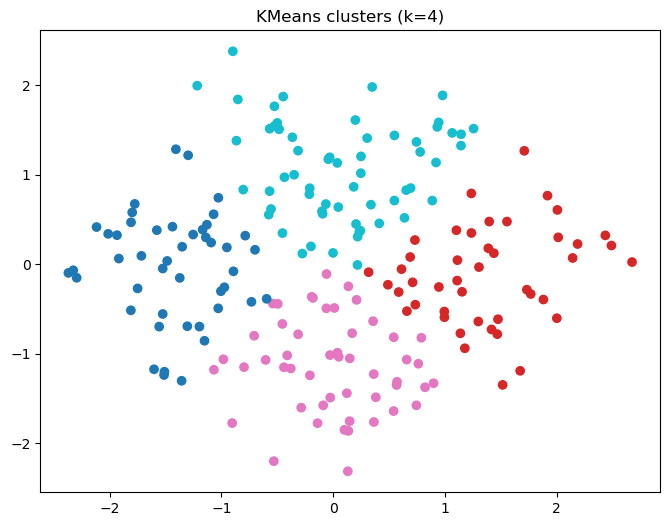

In [29]:
k_opt = max(scores, key=scores.get)
km = KMeans(n_clusters=k_opt, random_state=42)
labels = km.fit_predict(X_pca)
df['cluster'] = labels

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10')
plt.title(f'KMeans clusters (k={k_opt})')
plt.show()

# cluster centers in original feature space

In [32]:
centers = scaler.inverse_transform(pca.inverse_transform(km.cluster_centers_))
centers_df = pd.DataFrame(centers, columns=features)
print('\nCluster centers:')
print(centers_df)


Cluster centers:
         Age  AnnualIncome  SpendingScore
0  30.355256     51.586310      21.993488
1  54.698615    105.911033      76.049828
2  53.481543     49.062705      50.332772
3  31.747367    113.196817      49.957809


# Export cluster assignments

In [35]:
df.to_csv('customer_segments.csv', index=False)
print('\nSaved customer_segments.csv')


Saved customer_segments.csv
